In [23]:
from dotenv import load_dotenv
load_dotenv()
import os
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

TypeError: str expected, not NoneType

In [11]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


In [17]:
class BMIState(TypedDict):
    weight_kg:float
    height_m:float
    bmi:float
    category:str


def calculate_bmi(state:BMIState)->BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight/(height**2)
    state['bmi'] = round(bmi,2)
    return state

def label_bmi(state:BMIState)->BMIState:
    bmi = state['bmi']
    if bmi<18.5:
        state['category'] = "underweight"
    elif 18.5<=bmi<=25:
        state['category'] = "Normal"
    elif 25<=bmi<30:
        state['category'] = "Overweight"
    else:
        state['category'] = "obese"
    return state

In [18]:
graph = StateGraph(BMIState)

graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node("labelbmi",label_bmi)
graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi','labelbmi')
graph.add_edge("labelbmi",END)


workflow = graph.compile()



In [19]:
response = workflow.invoke({'weight_kg':80,'height_m':1.73})
print(response)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


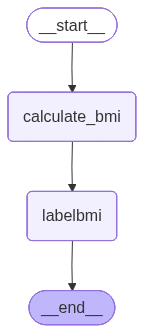

In [20]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())